The following code was used to extract the data partaining to the external field measurements

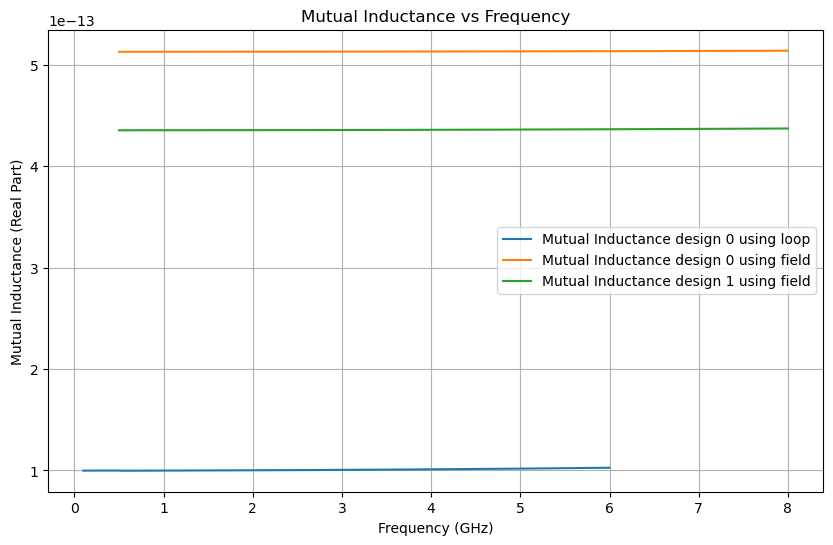

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

# 1. CHOOSE YOUR FILE HERE
filename = 'Mutual_ind_field_loop.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_1 = []
res_mags_1 = []

plt.figure(figsize=(10, 6))

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_1 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_1 = arr[:, 1]
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]
        imag_part = arr[:, 2]
        # Calculate total absolute magnitude from complex numbers
        mag_1 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_1)
    f_peak_1 = freq_1[peak_idx]
    mag_peak_1 = mag_1[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_1.append(f_peak_1)
    res_mags_1.append(mag_peak_1)
    
    # Dynamic Legend Label using the detected system identity
    label_name = f"{quantity_label} design 0 using loop"
    plt.plot(freq_1, mag_1, label=label_name)

# ///// Warcrimes from here on:

# 1. CHOOSE YOUR FILE HERE
filename = 'Design_0_mutual_inductance.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_2 = []
res_mags_2 = []

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_2 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_2 = arr[:, 1]
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]
        imag_part = arr[:, 2]
        # Calculate total absolute magnitude from complex numbers
        mag_2 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_2)
    f_peak_2 = freq_2[peak_idx]
    mag_peak_2 = mag_2[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_2.append(f_peak_2)
    res_mags_2.append(mag_peak_2)
    
    # Dynamic Legend Label using the detected system identity
    label_name = f"{quantity_label} design 0 using field"
    plt.plot(freq_2, mag_2, label=label_name)

#/////more warcrimes :

# 1. CHOOSE YOUR FILE HERE
filename = 'Design_1_mutual_inductance.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_3 = []
res_mags_3 = []

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_3 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_3 = arr[:, 1]
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]
        imag_part = arr[:, 2]
        # Calculate total absolute magnitude from complex numbers
        mag_3 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_3)
    f_peak_3 = freq_3[peak_idx]
    mag_peak_3 = mag_3[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_3.append(f_peak_3)
    res_mags_3.append(mag_peak_3)
    
    # Dynamic Legend Label using the detected system identity
    label_name = f"{quantity_label} design 1 using field"
    plt.plot(freq_3, mag_3, label=label_name)


plt.xlabel('Frequency (GHz)')
plt.ylabel(y_axis_title)
plt.title(f'{quantity_label} vs Frequency')
#plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

# Design 2 #

In [2]:
# 1. CHOOSE YOUR FILE HERE
filename = 'Design_2_mutual_inductance.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_4 = []
res_mags_4 = []

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_4 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_4 = arr[:, 1]
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]
        imag_part = arr[:, 2]
        # Calculate total absolute magnitude from complex numbers
        mag_4 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_4)
    f_peak_4 = freq_4[peak_idx]
    mag_peak_4 = mag_4[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_4.append(f_peak_4)
    res_mags_4.append(mag_peak_4)

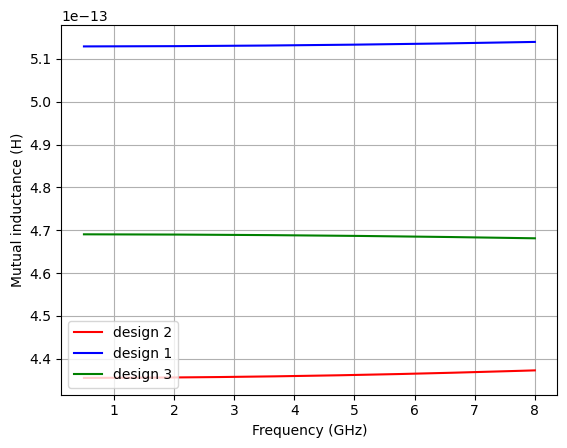

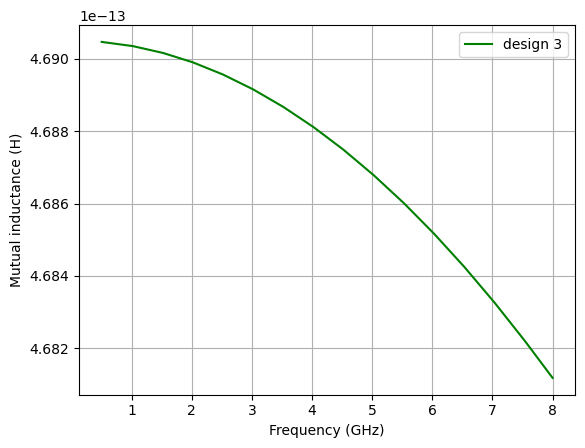

In [3]:
plt.plot(freq_3,mag_3, 'r', label='design 2')
plt.plot(freq_2,mag_2, 'b', label = 'design 1')
plt.plot(freq_4,mag_4, 'g', label = 'design 3')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Mutual inductance (H)')
plt.legend()
plt.grid(True)
#plt.savefig('Mutual_inductance_combined.pdf')
plt.show()

plt.plot(freq_4,mag_4, 'g', label = 'design 3')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Mutual inductance (H)')
plt.legend()
plt.grid(True)
#plt.savefig('Mutual_inductance_design3.pdf')
plt.show()

In [6]:
# 1. CHOOSE YOUR FILE HERE
filename = 'Design_2_flux_quanta.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_5 = []
res_mags_5 = []

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_5 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_5 = arr[:, 1]*np.pi #correcting for missing 2*pi in CST
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]*np.pi #correcting for missing 2*pi in CST
        imag_part = arr[:, 2]*np.pi #correcting for missing 2*pi in CST
        # Calculate total absolute magnitude from complex numbers
        mag_5 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_5)
    f_peak_5= freq_5[peak_idx]
    mag_peak_5 = mag_5[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_5.append(f_peak_5)
    res_mags_5.append(mag_peak_5)

#design 0 flux quanta:

# 1. CHOOSE YOUR FILE HERE
filename = 'Design_0_flux_quanta.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_6 = []
res_mags_6 = []

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_6 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_6 = arr[:, 1]*np.pi #correcting for missing 2*pi in CST
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]*np.pi #correcting for missing 2*pi in CST
        imag_part = arr[:, 2]*np.pi #correcting for missing 2*pi in CST
        # Calculate total absolute magnitude from complex numbers
        mag_6 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_6)
    f_peak_6= freq_6[peak_idx]
    mag_peak_6 = mag_6[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_6.append(f_peak_6)
    res_mags_6.append(mag_peak_6)


#Design 1 flux quanta
# 1. CHOOSE YOUR FILE HERE
filename = 'Design_1_flux_quanta.txt' 
# 2. AUTOMATIC LABEL DETECTION
filename_lower = filename.lower()
if 'flux' in filename_lower:
    quantity_label = 'Flux'
elif 'mutual' in filename_lower or 'ind' in filename_lower:
    quantity_label = 'Mutual Inductance'
else:
    quantity_label = 'Magnitude / Value'
# 3. FILE PARSING ENGINE
def parse_parameter_line(line):
    """Safely extracts all key-value parameters from the brace blocks."""
    match = re.search(r'\{(.*?)\}', line)
    params = {}
    if match:
        pairs = match.group(1).split(';')
        for pair in pairs:
            if '=' in pair:
                k, v = pair.split('=')
                k = k.strip()
                v = v.strip()
                try:
                    params[k] = float(v) if ('.' in v or 'e' in v.lower()) else int(v)
                except ValueError:
                    params[k] = v
    return params

current_sweep_idx = 0
data_sweeps = {}

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith('#Parameters'):
            params = parse_parameter_line(line)
            # Use 'inductance' as index key if present, otherwise fallback to sweep index
            sweep_key = params.get('inductance', f"Sweep_{current_sweep_idx}")
            
            if sweep_key in data_sweeps:
                sweep_key = f"{sweep_key}_run{current_sweep_idx}"
                
            data_sweeps[sweep_key] = {
                'params': params,
                'rows': []
            }
            current_sweep_idx += 1
            
        elif line.startswith('#'):
            continue  # Skip comments/labels
        else:
            parts = [float(x) for x in line.split()]
            if len(parts) >= 2 and current_sweep_idx > 0:
                active_key = list(data_sweeps.keys())[-1]
                data_sweeps[active_key]['rows'].append(parts)

# 4. PROCESSING & PLOTTING WITH NEW LABELS
tracking_keys = []
res_freqs_7 = []
res_mags_7 = []

for key in sorted(data_sweeps.keys(), key=lambda x: str(x)):
    sweep_data = data_sweeps[key]
    if not sweep_data['rows']:
        continue
        
    arr = np.array(sweep_data['rows'])
    freq_7 = arr[:, 0]  # Frequency (GHz)
    
    # Adapt to 2-column (Real Part only) or 3-column (Complex: Real + Imaginary) structures
    cols = arr.shape[1]
    if cols == 2:
        mag_7 = arr[:, 1]*np.pi #correcting for missing 2*pi in CST
        y_axis_title = f"{quantity_label} (Real Part)"
    elif cols >= 3:
        real_part = arr[:, 1]*np.pi #correcting for missing 2*pi in CST
        imag_part = arr[:, 2]*np.pi #correcting for missing 2*pi in CST
        # Calculate total absolute magnitude from complex numbers
        mag_7 = np.sqrt(real_part**2 + imag_part**2)
        y_axis_title = f"Total {quantity_label} Magnitude ($\sqrt{{Re^2 + Im^2}}$)"
    
    # Locate peak characteristic (Resonant frequency)
    peak_idx = np.argmax(mag_7)
    f_peak_7= freq_7[peak_idx]
    mag_peak_7 = mag_7[peak_idx]
    
    tracking_keys.append(key)
    res_freqs_7.append(f_peak_7)
    res_mags_7.append(mag_peak_7)

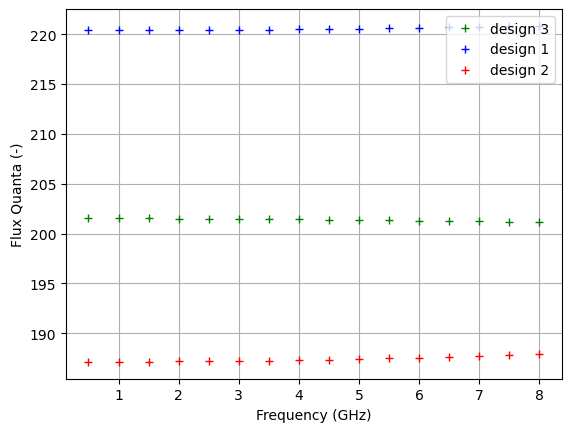

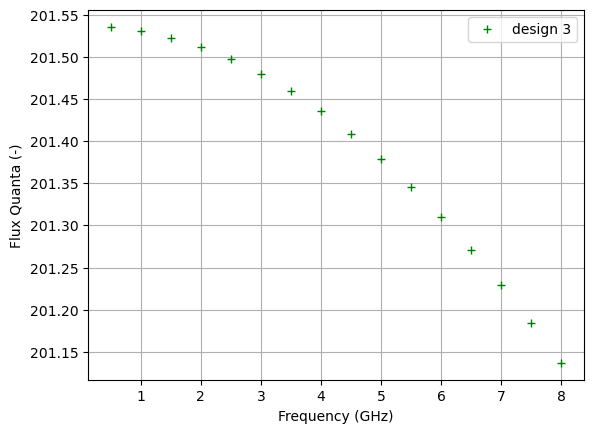

In [10]:
plt.plot(freq_5,mag_5, 'g+', label='design 3')
plt.plot(freq_6,mag_6, 'b+', label = 'design 1')
plt.plot(freq_7,mag_7, 'r+', label = 'design 2')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux Quanta (-)')
plt.legend()
plt.grid(True)
#plt.savefig('Flux_quanta_combined.pdf')
plt.show()

plt.plot(freq_5,mag_5, 'g+', label='design 3')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux Quanta (-)')
plt.legend()
plt.grid(True)
#plt.savefig('Flux_quanta_design3.pdf')
plt.show()